# Decision Tree - Model Evaluation

Evaluación de modelos de Árbol de Decisión (BALANCED vs RAW) con Cross-Validation Out-of-Fold.

> **Estrategia de evaluación:**  
> Se usa Cross-Validation Out-of-Fold (5-fold estratificado) sobre el conjunto de entrenamiento RAW original, aplicando ADASYN en el pipeline para el modelo balanceado. Esto evita el data leakage y produce métricas más realistas que evaluar sobre el mismo conjunto de entrenamiento.

## 1. Imports

In [13]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_fscore_support, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
print("✓ Libraries imported")

✓ Libraries imported


## 2. Load Data and Models

In [14]:
BASE_PATH = Path('../../..').resolve()
DATA_PATH = BASE_PATH / 'data' / 'processed' / 'pickle'
MODELS_PATH = BASE_PATH / 'models' / 'decision_tree'
RESULTS_PATH = BASE_PATH / 'data' / 'results' / 'decision_tree'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# Cargamos X_train y y_train (datos reales sin alterar) para Cross-Validation
with open(DATA_PATH / 'X_train_raw.pkl', 'rb') as f:
    X_train_raw = pickle.load(f)
with open(DATA_PATH / 'y_train_raw.pkl', 'rb') as f:
    y_train_raw = pickle.load(f)

if isinstance(X_train_raw, pd.DataFrame): X_train_raw = X_train_raw.values
if isinstance(y_train_raw, pd.DataFrame): y_train_raw = y_train_raw.iloc[:, 0]

# y_test apunta a y_train_raw para evaluación OOF
y_test = y_train_raw

# Cargamos modelos (solo para extraer sus hiperparámetros)
with open(MODELS_PATH / 'modelo_decision_tree_balanced.pkl', 'rb') as f:
    model_balanced = pickle.load(f)
with open(MODELS_PATH / 'modelo_decision_tree_raw.pkl', 'rb') as f:
    model_raw = pickle.load(f)

print(f"✓ Data for CV loaded  : shape {X_train_raw.shape}")
print(f"✓ Class distribution  : {dict(pd.Series(y_train_raw).value_counts().sort_index())}")
print(f"✓ Models loaded")

✓ Data for CV loaded  : shape (699, 651)
✓ Class distribution  : {0: np.int64(633), 1: np.int64(66)}
✓ Models loaded


## 3. Generate Out-of-Fold Predictions (5-Fold CV)

> Se generan predicciones Out-of-Fold usando el mismo protocolo que Regresión Logística:
> - **RAW**: DecisionTree con parámetros óptimos, directo sobre datos sin balancear.
> - **BALANCED**: Pipeline ADASYN + DecisionTree, aplicado dentro de cada fold para evitar data leakage.

In [15]:
print("Generando predicciones Out-of-Fold usando 5-Fold Stratified CV para Decision Tree...")

# Extraemos parámetros relevantes del Decision Tree
TRACKED_PARAMS = ['max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion', 'class_weight']
params_balanced = {k: v for k, v in model_balanced.get_params().items() if k in TRACKED_PARAMS}
params_raw   = {k: v for k, v in model_raw.get_params().items()   if k in TRACKED_PARAMS}

print(f"  BALANCED model params: {params_balanced}")
print(f"  RAW   model params: {params_raw}")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. PREDICCIONES CV MODELO RAW ---
cv_model_raw = DecisionTreeClassifier(random_state=42, **params_raw)
print("Calculando predicciones CV para RAW...")
y_pred_raw   = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict',       n_jobs=-1)
y_proba_raw  = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', n_jobs=-1)

# --- 2. PREDICCIONES CV MODELO ADASYN (PIPELINE) ---
# Evitamos class_weight='balanced' en el modelo dentro del pipeline
# para no doblar el peso con ADASYN
params_balanced_pipeline = {k: v for k, v in params_balanced.items() if k != 'class_weight'}
params_balanced_pipeline['class_weight'] = None

cv_model_adasyn = DecisionTreeClassifier(random_state=42, **params_balanced_pipeline)
adasyn_cv = ADASYN(sampling_strategy='auto', random_state=42, n_neighbors=5)
pipeline = ImbPipeline([('adasyn', adasyn_cv), ('dt', cv_model_adasyn)])

print("  Calculando predicciones CV para ADASYN (Pipeline)...")
y_pred_balanced  = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict',       n_jobs=-1)
y_proba_balanced = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', n_jobs=-1)

print("✓ Predicciones CV finalizadas.")
print("  Todas las métricas se calculan sobre predicciones Out-of-Fold — sin data leakage.")

Generando predicciones Out-of-Fold usando 5-Fold Stratified CV para Decision Tree...
  BALANCED model params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
  RAW   model params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
Calculando predicciones CV para RAW...
  Calculando predicciones CV para ADASYN (Pipeline)...
✓ Predicciones CV finalizadas.
  Todas las métricas se calculan sobre predicciones Out-of-Fold — sin data leakage.


## 4. Overall Metrics

In [16]:
print("" + "="*70)
print("OVERALL MODEL METRICS")  
print("="*70)

overall_metrics = {
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)',
               'F1-Score (macro)', "Cohen's Kappa",],
    'BALANCED': [
        f"{accuracy_score(y_test, y_pred_balanced):.4f}",
        f"{precision_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_balanced):.4f}",
    ],
    'RAW': [
        f"{accuracy_score(y_test, y_pred_raw):.4f}",
        f"{precision_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_raw):.4f}",
    ]
}

df_overall = pd.DataFrame(overall_metrics)
print("" + df_overall.to_string(index=False))

OVERALL MODEL METRICS
           Metric BALANCED    RAW
         Accuracy   0.8941 0.7368
Precision (macro)   0.6888 0.5774
   Recall (macro)   0.6837 0.6850
 F1-Score (macro)   0.6862 0.5729
    Cohen's Kappa   0.3724 0.1938


### 4.1 Overall Metrics — Visualization

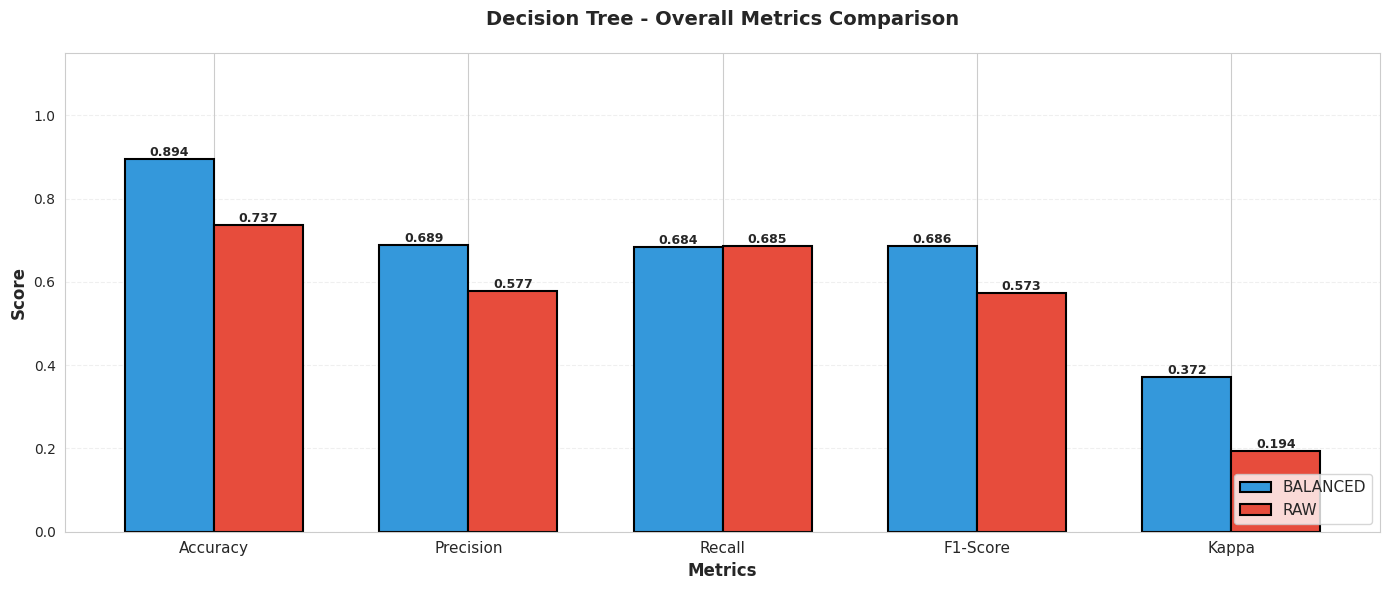

✓ Plot saved


In [ ]:
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', "Kappa"]
balanced_vals = [float(x) for x in df_overall['BALANCED'].values]
raw_vals   = [float(x) for x in df_overall['RAW'].values]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, balanced_vals, width, label='BALANCED', color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, raw_vals,   width, label='RAW',   color='#e74c3c', edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Decision Tree - Overall Metrics Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.15])
plt.tight_layout()
plt.show()
print("✓ Plot saved")

## 5. Per-Class Metrics

In [18]:
prec_s, rec_s, f1_s, sup_s = precision_recall_fscore_support(y_test, y_pred_balanced, average=None)
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sensitivity_s, specificity_s = [], []
for i in range(2):
    tp = cm_balanced[i, i]; fn = cm_balanced[i, :].sum() - tp
    fp = cm_balanced[:, i].sum() - tp; tn = cm_balanced.sum() - (tp + fn + fp)
    sensitivity_s.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity_s.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

df_class_balanced = pd.DataFrame({
    'Class': [0,1], 'Precision': prec_s, 'Recall': rec_s, 'F1-Score': f1_s,
    'Sensitivity': sensitivity_s, 'Specificity': specificity_s, 'Support': sup_s
})

prec_r, rec_r, f1_r, sup_r = precision_recall_fscore_support(y_test, y_pred_raw, average=None)
cm_raw = confusion_matrix(y_test, y_pred_raw)
sensitivity_r, specificity_r = [], []
for i in range(2):
    tp = cm_raw[i, i]; fn = cm_raw[i, :].sum() - tp
    fp = cm_raw[:, i].sum() - tp; tn = cm_raw.sum() - (tp + fn + fp)
    sensitivity_r.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity_r.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

df_class_raw = pd.DataFrame({
    'Class': [0,1], 'Precision': prec_r, 'Recall': rec_r, 'F1-Score': f1_r,
    'Sensitivity': sensitivity_r, 'Specificity': specificity_r, 'Support': sup_r
})

print("" + "="*70)
print("PER-CLASS METRICS - BALANCED MODEL")
print("="*70)
print("" + df_class_balanced.to_string(index=False))
print("" + "="*70)
print("PER-CLASS METRICS - RAW MODEL")
print("="*70)
print("" + df_class_raw.to_string(index=False))

PER-CLASS METRICS - BALANCED MODEL
 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0   0.940157 0.943128  0.941640     0.943128     0.424242      633
     1   0.437500 0.424242  0.430769     0.424242     0.943128       66
PER-CLASS METRICS - RAW MODEL
 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0     0.9499 0.748815  0.837456     0.748815     0.621212      633
     1     0.2050 0.621212  0.308271     0.621212     0.748815       66


### 5.1 Per-Class Metrics — Visualization

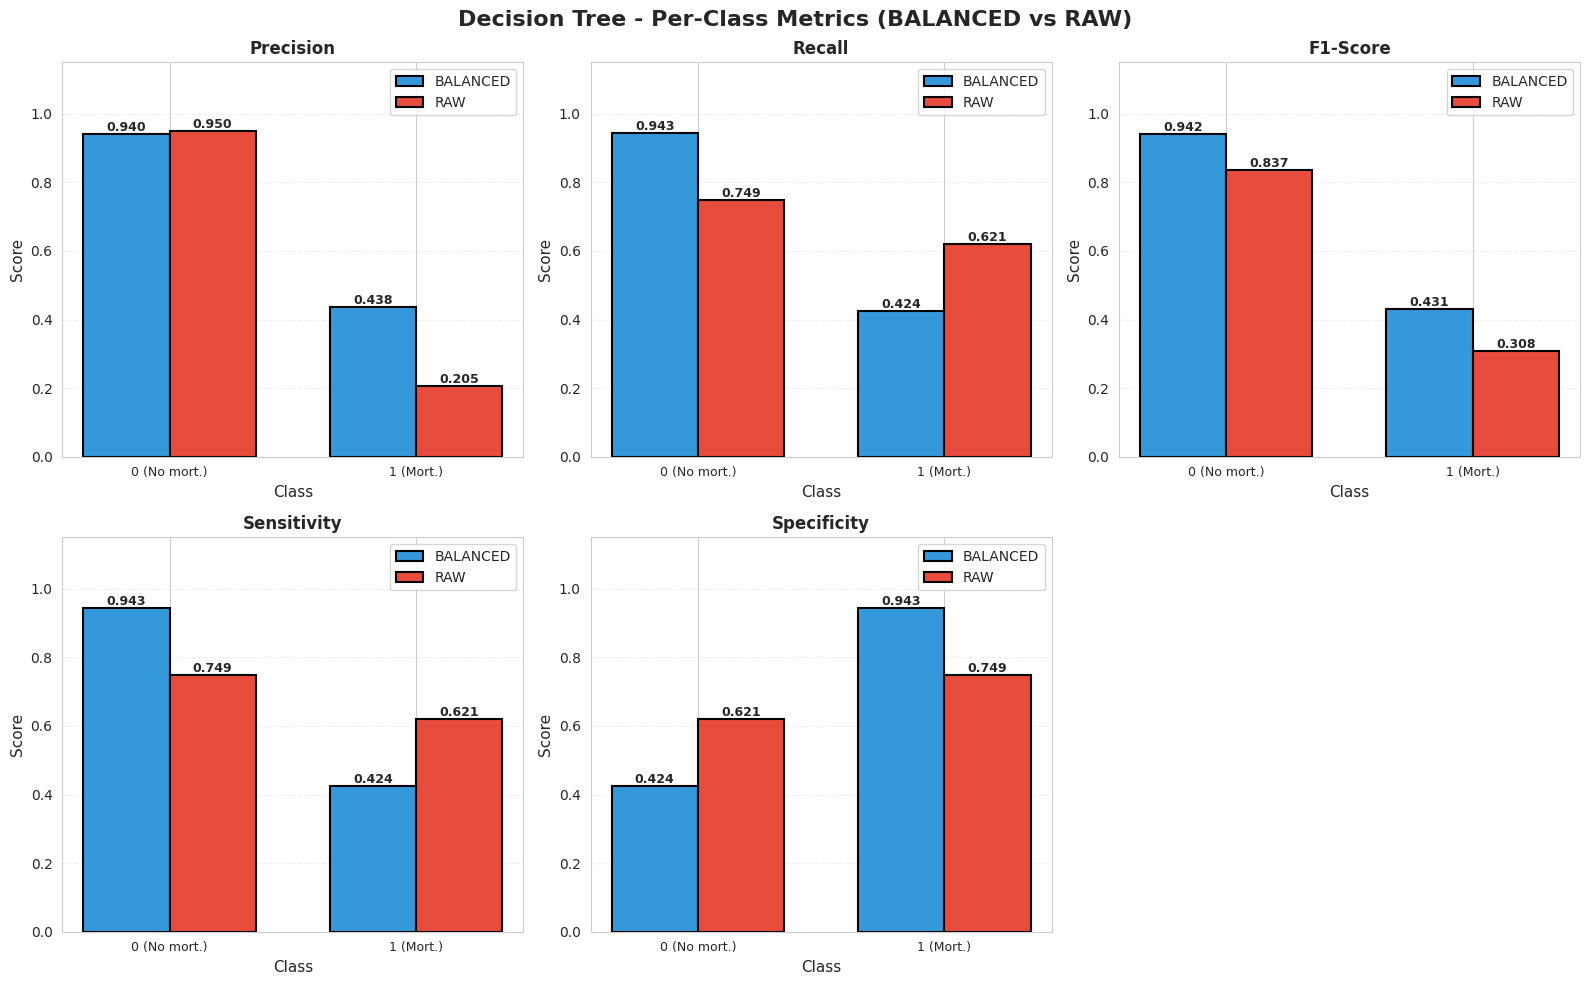

✓ Plot saved


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Decision Tree - Per-Class Metrics (BALANCED vs RAW)', fontsize=16, fontweight='bold')

data_map = {
    'Precision':   (prec_s, prec_r),
    'Recall':      (rec_s, rec_r),
    'F1-Score':    (f1_s, f1_r),
    'Sensitivity': (sensitivity_s, sensitivity_r),
    'Specificity': (specificity_s, specificity_r),
}

for idx, (metric, (balanced_data, raw_data)) in enumerate(data_map.items()):
    ax = axes[idx // 3][idx % 3]
    x = np.arange(2); width = 0.35
    bars1 = ax.bar(x - width/2, balanced_data, width, label='BALANCED', color='#3498db', edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, raw_data,   width, label='RAW',   color='#e74c3c', edgecolor='black', linewidth=1.5)
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['0 (No mort.)', '1 (Mort.)'], fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.15])

axes[1, 2].remove()
plt.tight_layout()
plt.show()
print("✓ Plot saved")

## 6. ROC-AUC Analysis

ROC-AUC SCORES (Binary)
BALANCED AUC: 0.6837
RAW   AUC: 0.7266


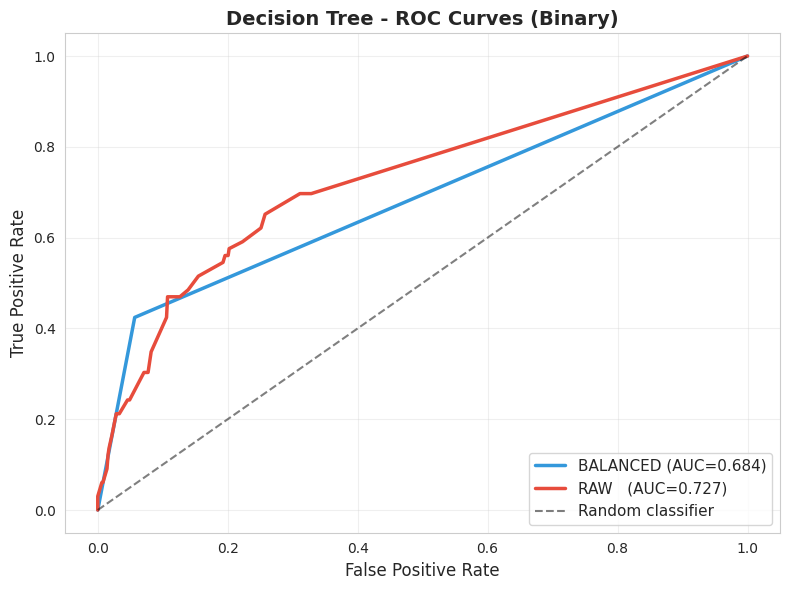

In [ ]:
print("" + "="*70)
print("ROC-AUC SCORES (Binary)")
print("="*70)

# En clasificación binaria, evaluamos usando la probabilidad de la clase positiva (Clase 1)
proba_1_balanced = y_proba_balanced[:, 1]
proba_1_raw   = y_proba_raw[:, 1]

roc_auc_balanced = roc_auc_score(y_test, proba_1_balanced)
roc_auc_raw   = roc_auc_score(y_test, proba_1_raw)

print(f"BALANCED AUC: {roc_auc_balanced:.4f}")
print(f"RAW   AUC: {roc_auc_raw:.4f}")

# Generar un único gráfico para la curva ROC binaria
plt.figure(figsize=(8, 6))

fpr_s, tpr_s, _ = roc_curve(y_test, proba_1_balanced)
fpr_r, tpr_r, _ = roc_curve(y_test, proba_1_raw)

plt.plot(fpr_s, tpr_s, color='#3498db', lw=2.5, label=f'BALANCED (AUC={roc_auc_balanced:.3f})')
plt.plot(fpr_r, tpr_r, color='#e74c3c', lw=2.5, label=f'RAW   (AUC={roc_auc_raw:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Decision Tree - ROC Curves (Binary)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Confusion Matrices

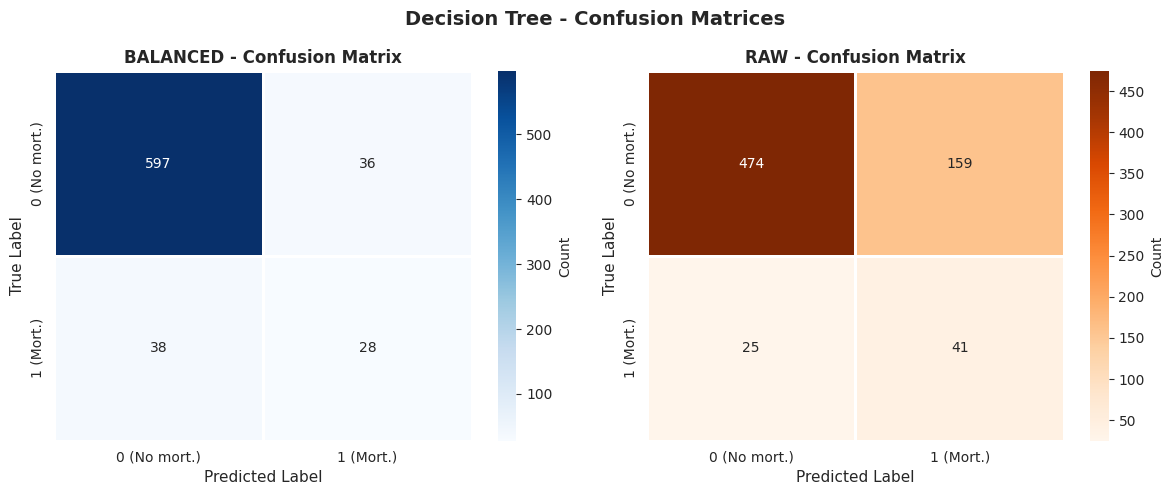

✓ Confusion matrices saved


In [ ]:
class_labels = ['0 (No mort.)', '1 (Mort.)']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Decision Tree - Confusion Matrices', fontsize=14, fontweight='bold')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, linewidths=2)
axes[0].set_title('BALANCED - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, linewidths=2)
axes[1].set_title('RAW - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()
print("✓ Confusion matrices saved")

## 8. Tree Visualization

> Una ventaja única de Decision Tree es la posibilidad de visualizar el árbol completo, mostrando las reglas de decisión en lenguaje clínico directo.

⚠️  feature_names.pkl not found — tree will show generic feature indices


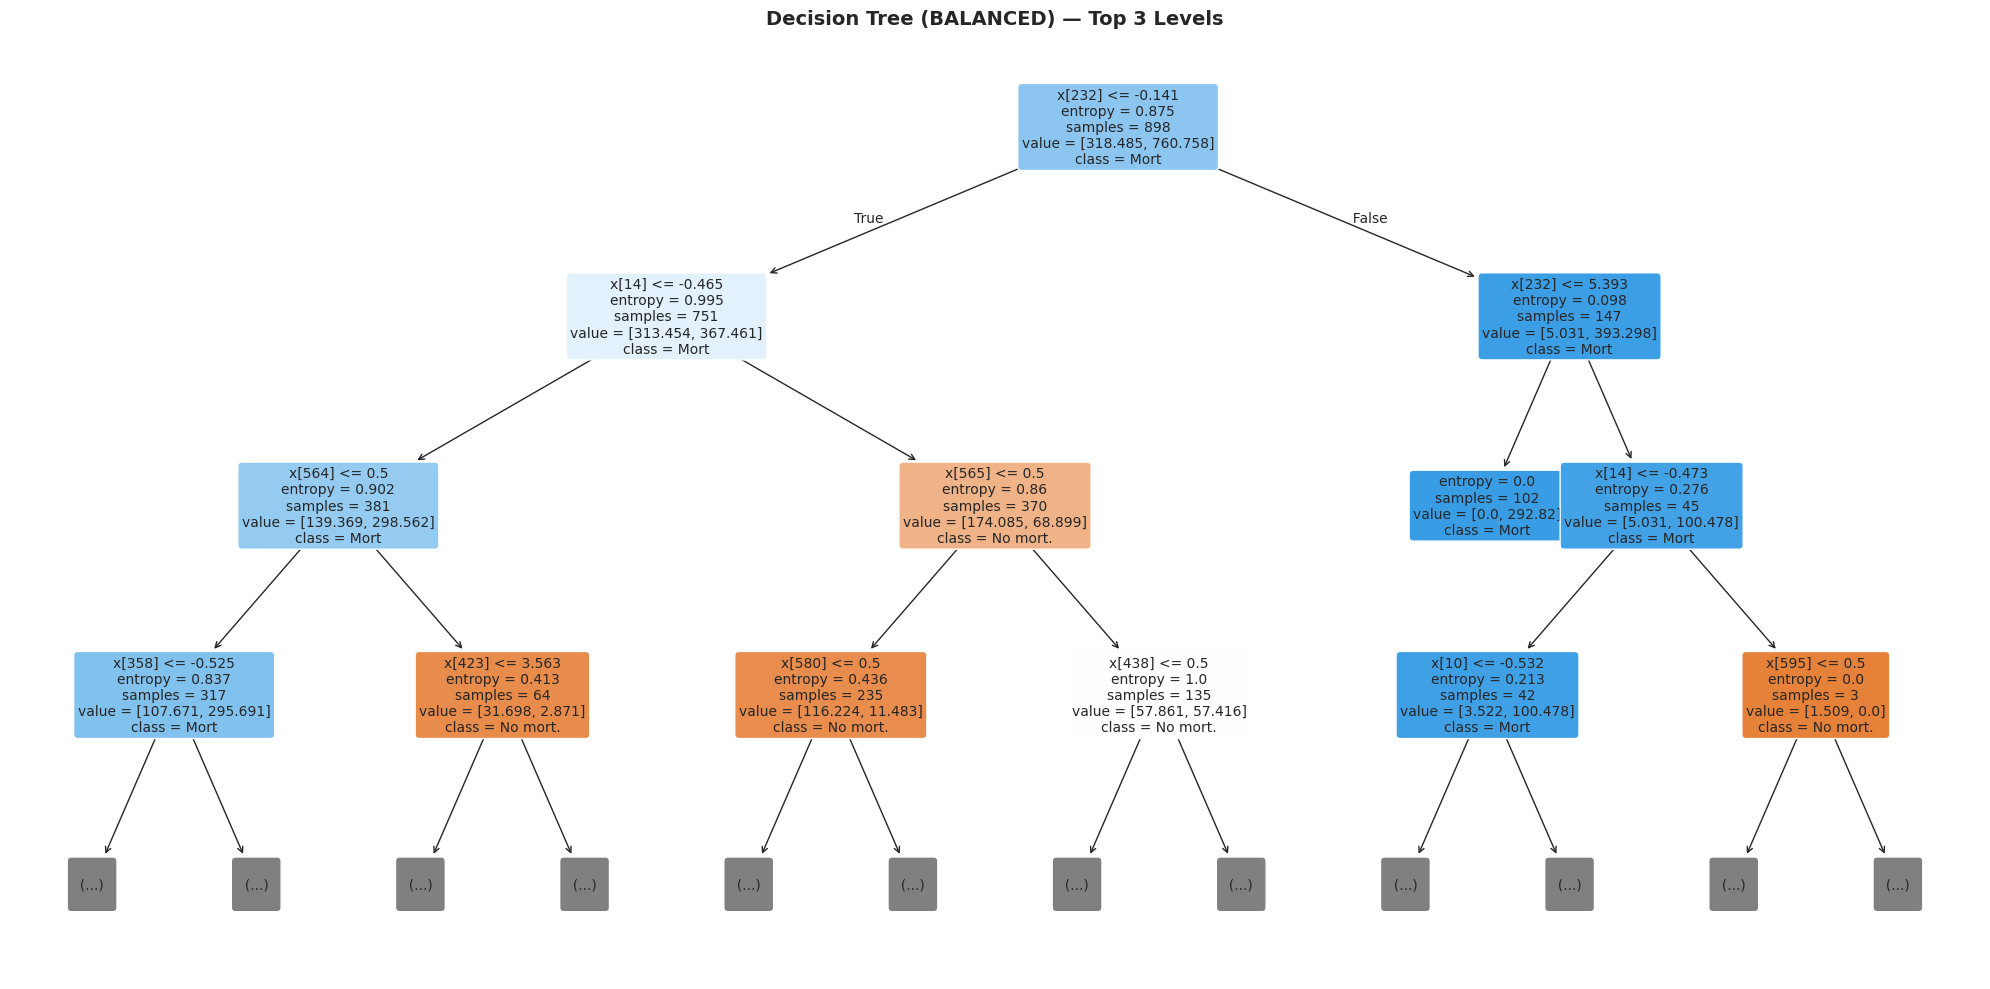

✓ Tree visualization saved


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Intentamos obtener los nombres de features si están disponibles
try:
    with open(DATA_PATH / 'feature_names.pkl', 'rb') as f:
        feature_names = pickle.load(f)
except:
    feature_names = None
    print("⚠️  feature_names.pkl not found — tree will show generic feature indices")

class_names = ['No mort.', 'Mort']

# Visualización BALANCED model
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    model_balanced,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,          # mostramos máximo 3 niveles para legibilidad
    ax=ax,
    fontsize=10
)
ax.set_title('Decision Tree (BALANCED) — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✓ Tree visualization saved")

## 9. Final Comparison

In [23]:
print("" + "="*70)
print("6. FINAL COMPARISON")
print("-" * 80)

print("Class 0 (No Muere):")
print(f"  BALANCED - Recall: {rec_s[0]:.4f} | Sensitivity: {sensitivity_s[0]:.4f} | Specificity: {specificity_s[0]:.4f}")
print(f"  RAW   - Recall: {rec_r[0]:.4f} | Sensitivity: {sensitivity_r[0]:.4f} | Specificity: {specificity_r[0]:.4f}")

print("\nClass 1 (Muere - Critical):")
print(f"  BALANCED - Recall: {rec_s[1]:.4f} | Sensitivity: {sensitivity_s[1]:.4f} | Specificity: {specificity_s[1]:.4f} | AUC: {roc_auc_balanced:.4f}")
print(f"  RAW   - Recall: {rec_r[1]:.4f} | Sensitivity: {sensitivity_r[1]:.4f} | Specificity: {specificity_r[1]:.4f} | AUC: {roc_auc_raw:.4f}")

mean_recall_balanced = np.mean([rec_s[0], rec_s[1]])
mean_recall_raw   = np.mean([rec_r[0], rec_r[1]])

print(f"\nMean Recall (macro): BALANCED={mean_recall_balanced:.4f}  |  RAW={mean_recall_raw:.4f}")
print(f"AUC:                 BALANCED={roc_auc_balanced:.4f}  |  RAW={roc_auc_raw:.4f}")

print("\n7. RECOMMENDATION")
print("-" * 80)
winner = "BALANCED" if mean_recall_balanced > mean_recall_raw else "RAW"
print(f"✅ RECOMMENDED MODEL: {winner}")
print("   (Higher average recall for mortality prediction)")
print("\nNote: Recall is prioritized for postoperative mortality risk prediction.")
print("      Detecting true deaths is more critical than avoiding false alarms.")
print("="*70)


6. FINAL COMPARISON
--------------------------------------------------------------------------------
Class 0 (No Muere):
  BALANCED - Recall: 0.9431 | Sensitivity: 0.9431 | Specificity: 0.4242
  RAW   - Recall: 0.7488 | Sensitivity: 0.7488 | Specificity: 0.6212

Class 1 (Muere - Critical):
  BALANCED - Recall: 0.4242 | Sensitivity: 0.4242 | Specificity: 0.9431 | AUC: 0.6837
  RAW   - Recall: 0.6212 | Sensitivity: 0.6212 | Specificity: 0.7488 | AUC: 0.7266

Mean Recall (macro): BALANCED=0.6837  |  RAW=0.6850
AUC:                 BALANCED=0.6837  |  RAW=0.7266

7. RECOMMENDATION
--------------------------------------------------------------------------------
✅ RECOMMENDED MODEL: RAW
   (Higher average recall for mortality prediction)

Note: Recall is prioritized for postoperative mortality risk prediction.
      Detecting true deaths is more critical than avoiding false alarms.


## 10. Save Results to File

In [24]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_filename = RESULTS_PATH / f"evaluation_results_{timestamp}.txt"

# Parámetros propios de Decision Tree
dt_params_keys = ['max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion', 'class_weight', 'random_state']
params_balanced_filtered = {k: v for k, v in model_balanced.get_params().items() if k in dt_params_keys}
params_raw_filtered   = {k: v for k, v in model_raw.get_params().items()   if k in dt_params_keys}

results_text = f"""
{'='*80}
DECISION TREE MODEL EVALUATION RESULTS (BINARY: muere / no muere)
Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*80}

0. MODEL HYPERPARAMETERS
{'-'*80}
BALANCED Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_balanced_filtered.items())}

RAW Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_raw_filtered.items())}

1. OVERALL MODEL METRICS
{'-'*80}
{df_overall.to_string(index=False)}

2. PER-CLASS METRICS - BALANCED MODEL
{'-'*80}
{df_class_balanced.to_string(index=False)}

3. PER-CLASS METRICS - RAW MODEL
{'-'*80}
{df_class_raw.to_string(index=False)}

4. ROC-AUC SCORES (Binary)
{'-'*80}
BALANCED AUC: {roc_auc_balanced:.4f}
RAW   AUC: {roc_auc_raw:.4f}

5. CONFUSION MATRICES
{'-'*80}
BALANCED:
{cm_balanced}

RAW:
{cm_raw}

6. FINAL COMPARISON
{'-'*80}
Class 0 (No Muere):
  BALANCED - Recall: {rec_s[0]:.4f} | Sensitivity: {sensitivity_s[0]:.4f} | Specificity: {specificity_s[0]:.4f}
  RAW   - Recall: {rec_r[0]:.4f} | Sensitivity: {sensitivity_r[0]:.4f} | Specificity: {specificity_r[0]:.4f}

Class 1 (Muere - Critical):
  BALANCED - Recall: {rec_s[1]:.4f} | Sensitivity: {sensitivity_s[1]:.4f} | Specificity: {specificity_s[1]:.4f} | AUC: {roc_auc_balanced:.4f}
  RAW   - Recall: {rec_r[1]:.4f} | Sensitivity: {sensitivity_r[1]:.4f} | Specificity: {specificity_r[1]:.4f} | AUC: {roc_auc_raw:.4f}

Mean Recall (macro): BALANCED={mean_recall_balanced:.4f}  |  RAW={mean_recall_raw:.4f}
AUC:                 BALANCED={roc_auc_balanced:.4f}  |  RAW={roc_auc_raw:.4f}

7. RECOMMENDATION
{'-'*80}
✅ RECOMMENDED MODEL: {winner.upper()}
   (Higher average recall for mortality prediction)

Note: Recall is prioritized for postoperative mortality risk prediction.
      Detecting true deaths is more critical than avoiding false alarms.
{'='*80}
"""

with open(results_filename, 'w') as f:
    f.write(results_text)

print(f"✓ Results saved → {results_filename.name}")
print(f"✅ Evaluation complete. Check {RESULTS_PATH} for all outputs.")


✓ Results saved → evaluation_results_2026-05-14_13-12-02.txt
✅ Evaluation complete. Check /home/pablo/Desktop/Estressss/pdg/data/results/decision_tree for all outputs.
